In [13]:
import importlib

import md_Helpers.Create_Lattices as cl
import md_Helpers.Simulation_Helpers as sh
import md_Helpers.viz_helpers as vh
import md_Helpers.Logging_Helpers as lh

importlib.reload(cl)
importlib.reload(sh)
importlib.reload(vh)
importlib.reload(lh)

<module 'md_Helpers.Logging_Helpers' from '/home/pnichols/MDsims/md_Helpers/Logging_Helpers.py'>

In [14]:
result = sh.get_or_make_thermalized_state(
    n_fcc_cells=30,
    target_rho=0.62,
    kT=0.96,
    nsteps=1_000_000,
    overwrite=False,
)


log = lh.read_hdf5_log(result["paths"]["log_path"])
log["metadata"]["attrs"]

Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/rho_0.620/kT_0.960/nsteps_1000000/seed_1/randomization.gsd


{'BoxLength': 55.848392486572266,
 'N': 108000,
 'actual_rho': 0.6200000494925489,
 'buffer_LJ': 0.4,
 'density_mode': 'fixed_N_variable_L',
 'dt': 0.005,
 'epsilon_LJ': 1.0,
 'fcc_cell_size': 1.8616130828857422,
 'final_timestep': 1000000,
 'kT': 0.96,
 'lattice_type': 'fcc',
 'lj_mode': 'xplor',
 'log_path': '/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/rho_0.620/kT_0.960/nsteps_1000000/seed_1/randomization_log.hdf5',
 'log_period': 1000,
 'n_fcc_cells': 30,
 'nsteps': 1000000,
 'phase_name': 'randomization',
 'phase_separated': False,
 'r_cut_LJ': 2.5,
 'r_on_LJ': 2.0,
 'seed': 1,
 'sigma_LJ': 1.0,
 'starting_state_path': '/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_30/rho_0.620/lattice.gsd',
 'state_path': '/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/rho_0.620/kT_0.960/nsteps_1000000/seed_1/randomization.gsd',
 'target_rho': 0.62,
 'volume': 174193.5344818032}

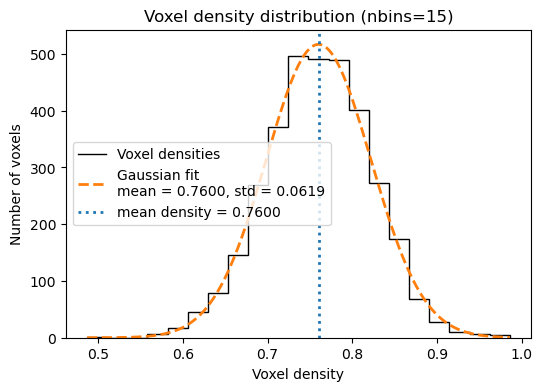

Voxel density summary
nbins:              15
number of voxels:   3375
voxel volume:       42.10526134071073
mean density:       0.7600000328001727
std density:        0.061857877755517404
min density:        0.49875002152511333
max density:        0.9737500420252213


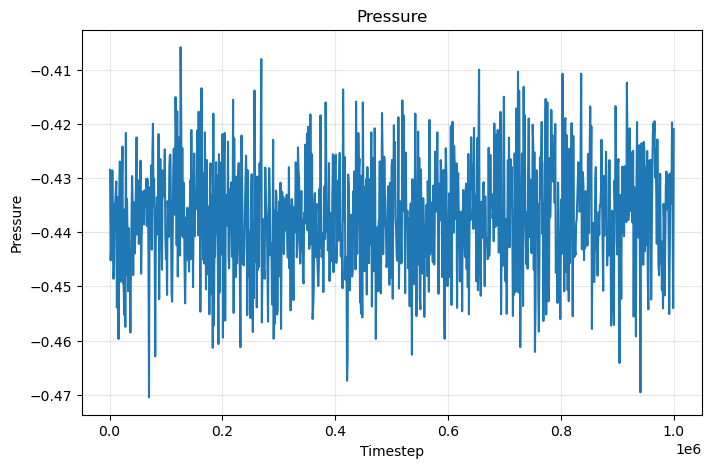

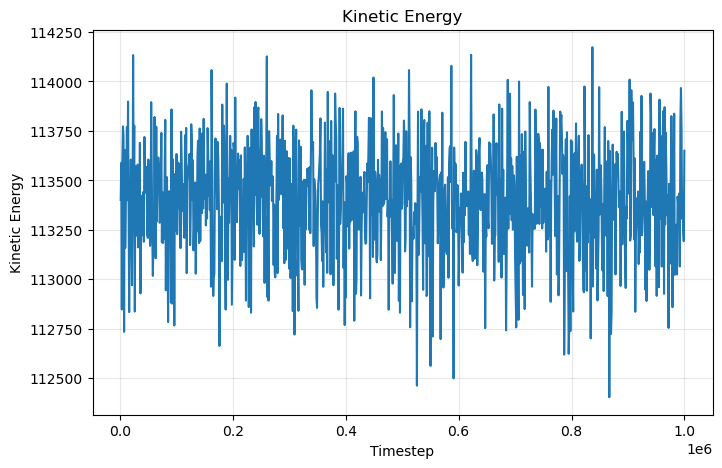

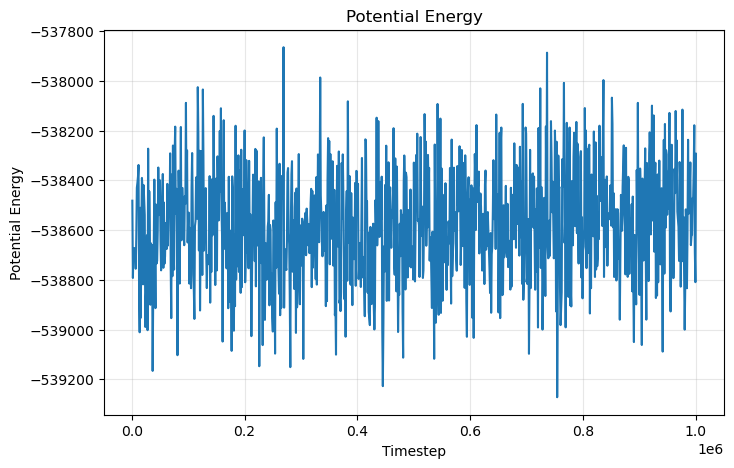

In [19]:
vh.plot_voxel_histogram(result, nbins=15)

vh.plot_log_quantity(log, "pressure")
vh.plot_log_quantity(log, "kinetic_energy")
vh.plot_log_quantity(log, "potential_energy")

In [4]:
log["metadata"]['phase_separation'].keys()

SyntaxError: invalid decimal literal (1809500777.py, line 1108)

In [19]:
#display(vh.render(result))

Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/rho_0.700/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
Loaded state metadata
n_fcc_cells:     30
N:               108000
target_rho:      0.7
actual_rho:      0.699999984804194
kT:              0.7
nsteps:          1000000
phase_separated: True
state_path:      /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/rho_0.700/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
log_path:        /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/rho_0.700/kT_0.700/nsteps_1000000/seed_1/randomization_log.hdf5

start 0: success=True, nll=9633.224
start 1: success=True, nll=9633.213
start 2: success=True, nll=14306.909
start 3: success=True, nll=9633.512
start 4: success=True, nll=9465.150
start 5: success=True, nll=9633.834
start 6: success=True, nll=9633.488
Voxel fit summary
nbins:        15
n_voxels:     3375
voxel_volume: 45.7143

Model com

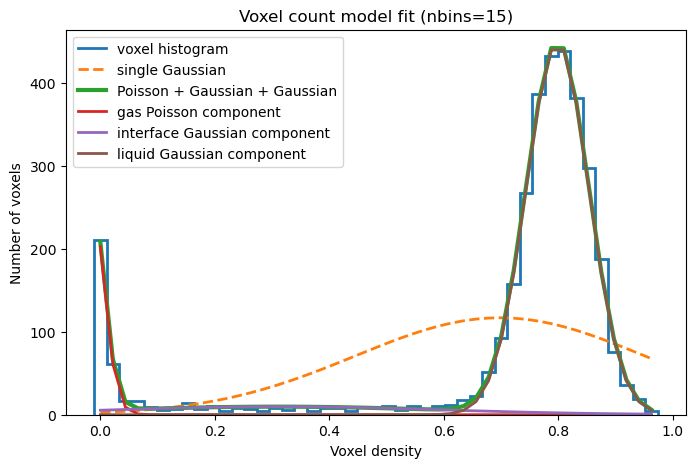

In [3]:
# ============================================================
# Full voxel count model fitting cell
#
# Models:
#   1. Single binned Gaussian
#   2. Poisson gas + Gaussian interface + Gaussian liquid
#
# Fit is done in integer voxel-count space.
# Plots and printed rho values are converted back to density space.
# ============================================================

import importlib

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.special import gammaln, logsumexp
from scipy.stats import norm

import md_Helpers.Simulation_Helpers as sh
import md_Helpers.Logging_Helpers as lh
import md_Helpers.viz_helpers as vh

importlib.reload(sh)
importlib.reload(lh)
importlib.reload(vh)


# ============================================================
# Probability helpers
# ============================================================

def _poisson_probs(
    k_values,
    lam,
):
    """
    Poisson probability for integer voxel counts.
    """

    k_values = np.asarray(
        k_values,
        dtype=np.float64,
    )

    lam = max(
        float(lam),
        1e-12,
    )

    log_probs = (
        k_values * np.log(lam)
        - lam
        - gammaln(k_values + 1.0)
    )

    return np.exp(log_probs)


def _binned_gaussian_probs(
    k_values,
    mu,
    sigma,
):
    """
    Probability for integer count k from a continuous Gaussian
    integrated over [k - 1/2, k + 1/2].

    This is better than evaluating the Gaussian PDF at k.
    """

    k_values = np.asarray(
        k_values,
        dtype=np.float64,
    )

    mu = float(mu)

    sigma = max(
        float(sigma),
        1e-12,
    )

    lower = k_values - 0.5
    upper = k_values + 0.5

    probs = (
        norm.cdf((upper - mu) / sigma)
        - norm.cdf((lower - mu) / sigma)
    )

    # Gaussian has unphysical mass below -0.5 counts.
    # Remove that mass so the nonnegative-count distribution is normalized.
    nonnegative_mass = (
        1.0
        - norm.cdf((-0.5 - mu) / sigma)
    )

    if nonnegative_mass > 0:
        probs = probs / nonnegative_mass

    return probs


def _safe_nll(
    hist_counts,
    probs,
):
    """
    Negative log likelihood for histogram counts.
    """

    probs = np.asarray(
        probs,
        dtype=np.float64,
    )

    probs = np.clip(
        probs,
        1e-300,
        None,
    )

    nll = -np.sum(
        hist_counts * np.log(probs)
    )

    return float(nll)


def _aic(
    nll,
    n_params,
):
    return float(
        2.0 * nll
        + 2.0 * n_params
    )


def _bic(
    nll,
    n_params,
    n_obs,
):
    return float(
        2.0 * nll
        + n_params * np.log(n_obs)
    )


def _softmax(
    logits,
):
    logits = np.asarray(
        logits,
        dtype=np.float64,
    )

    return np.exp(
        logits - logsumexp(logits)
    )


# ============================================================
# Get integer voxel-count histogram
# ============================================================

def get_voxel_count_histogram(
    obj,
    nbins=20,
):
    """
    Use vh.compute_voxel_densities, then make a histogram of integer
    particle counts per voxel.

    Returns
    -------
    hist_info : dict
        Contains the raw voxel counts, voxel densities, voxel volume,
        integer count values, and number of voxels with each count.
    """

    voxel_densities, voxel_counts, voxel_volume = vh.compute_voxel_densities(
        obj,
        nbins=nbins,
    )

    voxel_counts = np.asarray(
        voxel_counts,
        dtype=np.float64,
    )

    voxel_counts_int = np.rint(
        voxel_counts
    ).astype(int)

    if not np.allclose(voxel_counts, voxel_counts_int):
        raise ValueError(
            "voxel_counts were not integer-like. Something is wrong."
        )

    min_count = 0
    max_count = int(
        voxel_counts_int.max()
    )

    k_values = np.arange(
        min_count,
        max_count + 1,
        dtype=int,
    )

    hist_counts = np.bincount(
        voxel_counts_int,
        minlength=max_count + 1,
    )

    hist_info = {
        "voxel_densities": voxel_densities,
        "voxel_counts": voxel_counts_int,
        "voxel_volume": float(voxel_volume),

        "k_values": k_values,
        "hist_counts": hist_counts,

        "n_voxels": int(len(voxel_counts_int)),
        "nbins": int(nbins),
    }

    return hist_info


# ============================================================
# Fit single binned Gaussian
# ============================================================

def fit_single_gaussian_from_hist(
    k_values,
    hist_counts,
):
    """
    Fit one binned Gaussian to the voxel-count histogram.
    """

    k_values = np.asarray(
        k_values,
        dtype=np.float64,
    )

    hist_counts = np.asarray(
        hist_counts,
        dtype=np.float64,
    )

    n_obs = int(
        np.sum(hist_counts)
    )

    mean_start = float(
        np.sum(k_values * hist_counts) / n_obs
    )

    var_start = float(
        np.sum(hist_counts * (k_values - mean_start)**2) / n_obs
    )

    std_start = max(
        np.sqrt(var_start),
        0.5,
    )

    max_scale = max(
        float(k_values.max()) + 10.0,
        mean_start + 10.0,
        10.0,
    )

    def objective(theta):
        mu = theta[0]
        sigma = np.exp(theta[1])

        probs = _binned_gaussian_probs(
            k_values=k_values,
            mu=mu,
            sigma=sigma,
        )

        return _safe_nll(
            hist_counts=hist_counts,
            probs=probs,
        )

    starts = [
        [mean_start, np.log(std_start)],
        [mean_start, np.log(max(std_start / 2.0, 0.5))],
        [mean_start, np.log(max(std_start * 2.0, 0.5))],
    ]

    bounds = [
        (0.0, max_scale),
        (np.log(0.25), np.log(max_scale)),
    ]

    best = None

    for theta0 in starts:
        res = minimize(
            objective,
            theta0,
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": 2000,
            },
        )

        if best is None or res.fun < best.fun:
            best = res

    mu = float(best.x[0])
    sigma = float(np.exp(best.x[1]))

    probs = _binned_gaussian_probs(
        k_values=k_values,
        mu=mu,
        sigma=sigma,
    )

    nll = _safe_nll(
        hist_counts=hist_counts,
        probs=probs,
    )

    n_params = 2

    result = {
        "model_name": "single_gaussian",

        "mu": mu,
        "sigma": sigma,

        "nll": nll,
        "aic": _aic(nll, n_params),
        "bic": _bic(nll, n_params, n_obs),
        "n_params": n_params,

        "probs": probs,

        "success": bool(best.success),
        "message": best.message,
    }

    return result


# ============================================================
# Poisson + Gaussian + Gaussian parameter helpers
# ============================================================

def _unpack_pgg_params(
    theta,
):
    """
    Convert optimizer parameters into physical parameters.

    Enforced:
        weights are positive and sum to 1
        lambda_g > 0
        lambda_g < mu_i < mu_l
        sigma_i > 0
        sigma_l > 0
    """

    weights = _softmax(
        theta[0:3]
    )

    lambda_g = np.exp(
        theta[3]
    )

    delta_i = np.exp(
        theta[4]
    )

    delta_l = np.exp(
        theta[5]
    )

    mu_i = lambda_g + delta_i
    mu_l = mu_i + delta_l

    sigma_i = np.exp(
        theta[6]
    )

    sigma_l = np.exp(
        theta[7]
    )

    params = {
        "w_g": float(weights[0]),
        "w_i": float(weights[1]),
        "w_l": float(weights[2]),

        "lambda_g": float(lambda_g),

        "mu_i": float(mu_i),
        "sigma_i": float(sigma_i),

        "mu_l": float(mu_l),
        "sigma_l": float(sigma_l),
    }

    return params


def _make_pgg_theta_start(
    weights,
    lambda_g,
    mu_i,
    mu_l,
    sigma_i,
    sigma_l,
):
    """
    Make one initial optimizer vector from physical guesses.
    """

    weights = np.asarray(
        weights,
        dtype=np.float64,
    )

    weights = weights / np.sum(weights)

    lambda_g = max(
        float(lambda_g),
        1e-4,
    )

    mu_i = max(
        float(mu_i),
        lambda_g + 1e-3,
    )

    mu_l = max(
        float(mu_l),
        mu_i + 1e-3,
    )

    sigma_i = max(
        float(sigma_i),
        0.25,
    )

    sigma_l = max(
        float(sigma_l),
        0.25,
    )

    theta = np.array(
        [
            np.log(weights[0]),
            np.log(weights[1]),
            np.log(weights[2]),

            np.log(lambda_g),
            np.log(mu_i - lambda_g),
            np.log(mu_l - mu_i),

            np.log(sigma_i),
            np.log(sigma_l),
        ],
        dtype=np.float64,
    )

    return theta


def _pgg_component_probs(
    k_values,
    params,
):
    """
    Return gas, interface, liquid, and total probabilities.
    """

    p_g = _poisson_probs(
        k_values=k_values,
        lam=params["lambda_g"],
    )

    p_i = _binned_gaussian_probs(
        k_values=k_values,
        mu=params["mu_i"],
        sigma=params["sigma_i"],
    )

    p_l = _binned_gaussian_probs(
        k_values=k_values,
        mu=params["mu_l"],
        sigma=params["sigma_l"],
    )

    total = (
        params["w_g"] * p_g
        + params["w_i"] * p_i
        + params["w_l"] * p_l
    )

    return p_g, p_i, p_l, total


# ============================================================
# Fit Poisson + Gaussian + Gaussian
# ============================================================

def fit_poisson_gaussian_gaussian_from_hist(
    k_values,
    hist_counts,
    verbose=False,
):
    """
    Fit:
        gas:        Poisson
        interface:  binned Gaussian
        liquid:     binned Gaussian
    """

    k_values = np.asarray(
        k_values,
        dtype=np.float64,
    )

    hist_counts = np.asarray(
        hist_counts,
        dtype=np.float64,
    )

    n_obs = int(
        np.sum(hist_counts)
    )

    expanded_counts = np.repeat(
        k_values,
        hist_counts.astype(int),
    )

    mean_count = float(
        np.mean(expanded_counts)
    )

    std_count = float(
        np.std(expanded_counts, ddof=1)
    )

    q01, q05, q20, q50, q80, q95, q99 = np.percentile(
        expanded_counts,
        [1, 5, 20, 50, 80, 95, 99],
    )

    max_scale = max(
        float(k_values.max()) + 10.0,
        mean_count + 10.0,
        10.0,
    )

    def objective(theta):
        params = _unpack_pgg_params(
            theta
        )

        _, _, _, total_probs = _pgg_component_probs(
            k_values=k_values,
            params=params,
        )

        return _safe_nll(
            hist_counts=hist_counts,
            probs=total_probs,
        )

    # ------------------------------------------------------------
    # Multi-start guesses
    # ------------------------------------------------------------
    starts_physical = [
        # weights, lambda_g, mu_i, mu_l, sigma_i, sigma_l
        ([0.20, 0.20, 0.60], q05, q50, q95, 1.0, max(std_count / 2.0, 1.0)),
        ([0.30, 0.20, 0.50], q05, q50, q80, 1.0, max(std_count / 2.0, 1.0)),
        ([0.10, 0.30, 0.60], q20, q50, q95, 1.0, max(std_count / 2.0, 1.0)),
        ([0.50, 0.20, 0.30], q05, q50, q80, 1.0, max(std_count / 2.0, 1.0)),
        ([0.10, 0.10, 0.80], q01, q20, q99, 1.0, max(std_count / 2.0, 1.0)),
        ([0.05, 0.10, 0.85], q01, q50, q95, 1.0, max(std_count / 2.0, 1.0)),
        ([0.05, 0.20, 0.75], q05, q50, q99, 1.0, max(std_count / 2.0, 1.0)),
    ]

    theta_starts = []

    for row in starts_physical:
        weights, lambda_g, mu_i, mu_l, sigma_i, sigma_l = row

        lambda_g = max(
            float(lambda_g),
            1e-3,
        )

        mu_i = max(
            float(mu_i),
            lambda_g + 0.5,
        )

        mu_l = max(
            float(mu_l),
            mu_i + 0.5,
        )

        theta_starts.append(
            _make_pgg_theta_start(
                weights=weights,
                lambda_g=lambda_g,
                mu_i=mu_i,
                mu_l=mu_l,
                sigma_i=sigma_i,
                sigma_l=sigma_l,
            )
        )

    bounds = [
        (-10.0, 10.0),                         # gas weight logit
        (-10.0, 10.0),                         # interface weight logit
        (-10.0, 10.0),                         # liquid weight logit

        (np.log(1e-4), np.log(max_scale)),     # lambda_g
        (np.log(1e-4), np.log(max_scale)),     # mu_i - lambda_g
        (np.log(1e-4), np.log(max_scale)),     # mu_l - mu_i

        (np.log(0.25), np.log(max_scale)),     # sigma_i
        (np.log(0.25), np.log(max_scale)),     # sigma_l
    ]

    best = None

    for i, theta0 in enumerate(theta_starts):
        res = minimize(
            objective,
            theta0,
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": 5000,
            },
        )

        if verbose:
            print(
                f"start {i}: "
                f"success={res.success}, "
                f"nll={res.fun:.3f}"
            )

        if best is None or res.fun < best.fun:
            best = res

    params = _unpack_pgg_params(
        best.x
    )

    p_g, p_i, p_l, total_probs = _pgg_component_probs(
        k_values=k_values,
        params=params,
    )

    nll = _safe_nll(
        hist_counts=hist_counts,
        probs=total_probs,
    )

    # Independent physical parameters:
    #   2 independent weights + lambda_g + mu_i + sigma_i + mu_l + sigma_l
    n_params = 7

    result = {
        "model_name": "poisson_gaussian_gaussian",

        **params,

        "nll": nll,
        "aic": _aic(nll, n_params),
        "bic": _bic(nll, n_params, n_obs),
        "n_params": n_params,

        "probs": total_probs,

        "component_probs": {
            "gas": p_g,
            "interface": p_i,
            "liquid": p_l,
        },

        "success": bool(best.success),
        "message": best.message,
    }

    return result


# ============================================================
# Main fit function
# ============================================================

def fit_voxel_count_model(
    obj,
    nbins=20,
    verbose=False,
):
    """
    Fit voxel count models for one object.

    Models:
    - single binned Gaussian
    - Poisson gas + Gaussian interface + Gaussian liquid
    """

    hist_info = get_voxel_count_histogram(
        obj=obj,
        nbins=nbins,
    )

    k_values = hist_info["k_values"]
    hist_counts = hist_info["hist_counts"]
    voxel_volume = hist_info["voxel_volume"]

    single_gaussian = fit_single_gaussian_from_hist(
        k_values=k_values,
        hist_counts=hist_counts,
    )

    pgg = fit_poisson_gaussian_gaussian_from_hist(
        k_values=k_values,
        hist_counts=hist_counts,
        verbose=verbose,
    )

    # ------------------------------------------------------------
    # Add density-space versions of count parameters
    # ------------------------------------------------------------
    single_gaussian["rho_mu"] = (
        single_gaussian["mu"] / voxel_volume
    )

    single_gaussian["rho_sigma"] = (
        single_gaussian["sigma"] / voxel_volume
    )

    pgg["rho_g"] = (
        pgg["lambda_g"] / voxel_volume
    )

    pgg["rho_i"] = (
        pgg["mu_i"] / voxel_volume
    )

    pgg["rho_l"] = (
        pgg["mu_l"] / voxel_volume
    )

    pgg["rho_sigma_i"] = (
        pgg["sigma_i"] / voxel_volume
    )

    pgg["rho_sigma_l"] = (
        pgg["sigma_l"] / voxel_volume
    )

    pgg["delta_bic_vs_gaussian"] = (
        single_gaussian["bic"] - pgg["bic"]
    )

    pgg["rho_l_minus_rho_g"] = (
        pgg["rho_l"] - pgg["rho_g"]
    )

    fit = {
        **hist_info,
        "single_gaussian": single_gaussian,
        "poisson_gaussian_gaussian": pgg,
    }

    return fit


# ============================================================
# Plot fit
# ============================================================

def plot_voxel_count_model_fit(
    fit,
    show_single_gaussian=True,
):
    """
    Plot histogram and model fits.

    X-axis is voxel density.
    Y-axis is number of voxels per integer-count bin.
    """

    k_values = fit["k_values"]
    hist_counts = fit["hist_counts"]
    voxel_volume = fit["voxel_volume"]
    n_voxels = fit["n_voxels"]
    nbins = fit["nbins"]

    x_centers = k_values / voxel_volume

    count_edges = np.arange(
        k_values.min() - 0.5,
        k_values.max() + 1.5,
        1.0,
    )

    density_edges = count_edges / voxel_volume

    p_gauss = fit["single_gaussian"]["probs"]

    pgg = fit["poisson_gaussian_gaussian"]

    p_g = pgg["component_probs"]["gas"]
    p_i = pgg["component_probs"]["interface"]
    p_l = pgg["component_probs"]["liquid"]
    p_total = pgg["probs"]

    plt.figure(figsize=(8, 5))

    plt.stairs(
        hist_counts,
        edges=density_edges,
        label="voxel histogram",
        linewidth=2,
    )

    if show_single_gaussian:
        plt.plot(
            x_centers,
            n_voxels * p_gauss,
            linestyle="--",
            linewidth=2,
            label="single Gaussian",
        )

    plt.plot(
        x_centers,
        n_voxels * p_total,
        linewidth=3,
        label="Poisson + Gaussian + Gaussian",
    )

    plt.plot(
        x_centers,
        n_voxels * pgg["w_g"] * p_g,
        linewidth=2,
        label="gas Poisson component",
    )

    plt.plot(
        x_centers,
        n_voxels * pgg["w_i"] * p_i,
        linewidth=2,
        label="interface Gaussian component",
    )

    plt.plot(
        x_centers,
        n_voxels * pgg["w_l"] * p_l,
        linewidth=2,
        label="liquid Gaussian component",
    )

    plt.xlabel("Voxel density")
    plt.ylabel("Number of voxels")
    plt.title(f"Voxel count model fit (nbins={nbins})")
    plt.legend()
    plt.show()


# ============================================================
# Print fit summary
# ============================================================

def print_voxel_fit_summary(
    fit,
):
    voxel_volume = fit["voxel_volume"]

    sg = fit["single_gaussian"]
    pgg = fit["poisson_gaussian_gaussian"]

    print("Voxel fit summary")
    print("=" * 70)
    print(f"nbins:        {fit['nbins']}")
    print(f"n_voxels:     {fit['n_voxels']}")
    print(f"voxel_volume: {voxel_volume:.6g}")
    print()

    print("Model comparison")
    print("-" * 70)
    print(f"single Gaussian:               NLL = {sg['nll']:.3f}, BIC = {sg['bic']:.3f}")
    print(f"Poisson + Gaussian + Gaussian: NLL = {pgg['nll']:.3f}, BIC = {pgg['bic']:.3f}")
    print(f"delta_BIC = single Gaussian BIC - mixture BIC = {sg['bic'] - pgg['bic']:.3f}")
    print()

    print("Single Gaussian")
    print("-" * 70)
    print(f"success:     {sg['success']}")
    print(f"message:     {sg['message']}")
    print(f"mu_count:    {sg['mu']:.6g}")
    print(f"sigma_count: {sg['sigma']:.6g}")
    print(f"rho_mu:      {sg['rho_mu']:.6g}")
    print(f"rho_sigma:   {sg['rho_sigma']:.6g}")
    print()

    print("Poisson + Gaussian + Gaussian")
    print("-" * 70)
    print(f"success: {pgg['success']}")
    print(f"message: {pgg['message']}")
    print()
    print(f"w_g = {pgg['w_g']:.6g}")
    print(f"lambda_g_count = {pgg['lambda_g']:.6g}")
    print(f"rho_g          = {pgg['rho_g']:.6g}")
    print()
    print(f"w_i = {pgg['w_i']:.6g}")
    print(f"mu_i_count    = {pgg['mu_i']:.6g}")
    print(f"sigma_i_count = {pgg['sigma_i']:.6g}")
    print(f"rho_i         = {pgg['rho_i']:.6g}")
    print(f"rho_sigma_i   = {pgg['rho_sigma_i']:.6g}")
    print()
    print(f"w_l = {pgg['w_l']:.6g}")
    print(f"mu_l_count    = {pgg['mu_l']:.6g}")
    print(f"sigma_l_count = {pgg['sigma_l']:.6g}")
    print(f"rho_l         = {pgg['rho_l']:.6g}")
    print(f"rho_sigma_l   = {pgg['rho_sigma_l']:.6g}")
    print()
    print(f"rho_l - rho_g = {pgg['rho_l_minus_rho_g']:.6g}")
    print("=" * 70)


# ============================================================
# Optional nbins scan helper
# ============================================================

def scan_voxel_model_vs_nbins(
    obj,
    nbins_values=(8, 10, 12, 15, 20, 25, 30),
):
    """
    Fit the same state with several voxel resolutions.
    """

    import pandas as pd

    rows = []

    for nb in nbins_values:
        fit_nb = fit_voxel_count_model(
            obj=obj,
            nbins=nb,
            verbose=False,
        )

        sg = fit_nb["single_gaussian"]
        pgg = fit_nb["poisson_gaussian_gaussian"]

        rows.append({
            "nbins": nb,
            "n_voxels": fit_nb["n_voxels"],
            "voxel_volume": fit_nb["voxel_volume"],

            "single_gaussian_bic": sg["bic"],
            "pgg_bic": pgg["bic"],
            "delta_bic_vs_gaussian": sg["bic"] - pgg["bic"],

            "w_g": pgg["w_g"],
            "rho_g": pgg["rho_g"],

            "w_i": pgg["w_i"],
            "rho_i": pgg["rho_i"],

            "w_l": pgg["w_l"],
            "rho_l": pgg["rho_l"],

            "rho_l_minus_rho_g": pgg["rho_l"] - pgg["rho_g"],

            "success": pgg["success"],
        })

    fit_scan_df = pd.DataFrame(rows)

    return fit_scan_df


# ============================================================
# Choose state to fit
# ============================================================

n_fcc_cells = 30
target_rho = 0.7
kT = 0.70
nsteps = 1_000_000
seed = 1
fit_nbins = 15


# ============================================================
# Load or make state
# ============================================================

result = sh.get_or_make_thermalized_state(
    n_fcc_cells=n_fcc_cells,
    target_rho=target_rho,
    kT=kT,
    nsteps=nsteps,
    seed=seed,
    overwrite=False,
)


# ============================================================
# Read metadata for sanity check
# ============================================================

log = lh.read_hdf5_log(
    result["paths"]["log_path"]
)

metadata = log["metadata"]["attrs"]

print("Loaded state metadata")
print("=" * 70)
print(f"n_fcc_cells:     {metadata.get('n_fcc_cells')}")
print(f"N:               {metadata.get('N')}")
print(f"target_rho:      {metadata.get('target_rho')}")
print(f"actual_rho:      {metadata.get('actual_rho')}")
print(f"kT:              {metadata.get('kT')}")
print(f"nsteps:          {metadata.get('nsteps')}")
print(f"phase_separated: {metadata.get('phase_separated')}")
print(f"state_path:      {result['paths']['state_path']}")
print(f"log_path:        {result['paths']['log_path']}")
print("=" * 70)
print()


# ============================================================
# Fit selected nbins
# ============================================================

fit = fit_voxel_count_model(
    result,
    nbins=fit_nbins,
    verbose=True,
)

print_voxel_fit_summary(
    fit,
)

plot_voxel_count_model_fit(
    fit,
    show_single_gaussian=True,
)

Voxel fit summary
nbins:        15
n_voxels:     3375
voxel_volume: 64

Model comparison
----------------------------------------------------------------------
single Gaussian:               NLL = 14909.270, BIC = 29834.788
Poisson + Gaussian + Gaussian: NLL = 10437.749, BIC = 20932.367
delta_BIC = single Gaussian BIC - mixture BIC = 8902.421

Single Gaussian
----------------------------------------------------------------------
mu_count    = 8.08324
sigma_count = 36.535
rho_mu      = 0.126301
rho_sigma   = 0.570859

Poisson + Gaussian + Gaussian
----------------------------------------------------------------------
success: True
message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

w_g = 0.293478
lambda_g_count = 0.355154
rho_g          = 0.00554928

w_i = 0.157193
mu_i_count    = 0.407742
sigma_i_count = 28.3084
rho_i         = 0.00637097
rho_sigma_i   = 0.442318

w_l = 0.549329
mu_l_count    = 51.395
sigma_l_count = 2.88976
rho_l         = 0.803047
rho_sigma_l   = 0.0451525

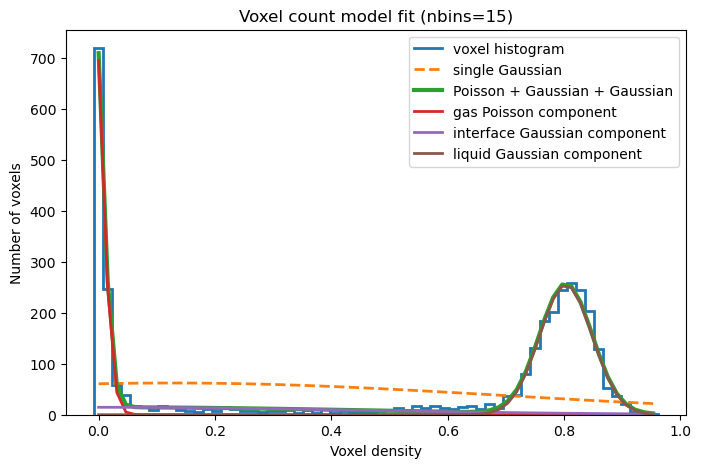

Voxel fit summary
nbins:        20
n_voxels:     8000
voxel_volume: 27

Model comparison
----------------------------------------------------------------------
single Gaussian:               NLL = 28596.542, BIC = 57211.059
Poisson + Gaussian + Gaussian: NLL = 20233.681, BIC = 40530.273
delta_BIC = single Gaussian BIC - mixture BIC = 16680.786

Single Gaussian
----------------------------------------------------------------------
mu_count    = 3.33317
sigma_count = 15.6627
rho_mu      = 0.123451
rho_sigma   = 0.5801

Poisson + Gaussian + Gaussian
----------------------------------------------------------------------
success: True
message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

w_g = 0.319698
lambda_g_count = 0.166847
rho_g          = 0.00617951

w_i = 0.102019
mu_i_count    = 7.08508
sigma_i_count = 7.61285
rho_i         = 0.262411
rho_sigma_i   = 0.281957

w_l = 0.578283
mu_l_count    = 21.6141
sigma_l_count = 2.08535
rho_l         = 0.800523
rho_sigma_l   = 0.0772352


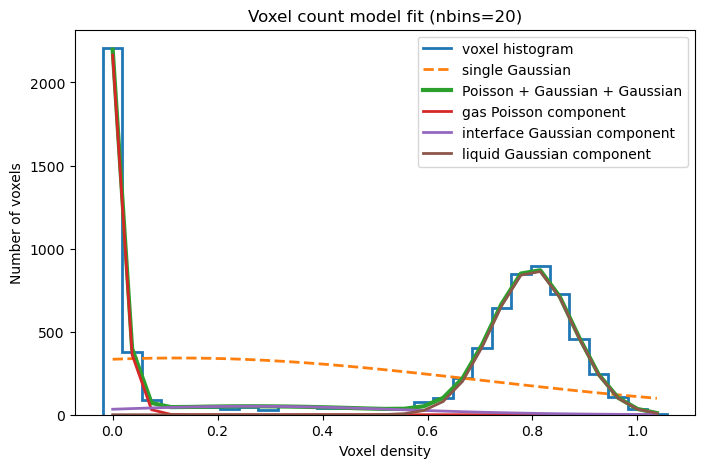

In [22]:
for nb in [15, 20]:
    fit_nb = fit_voxel_count_model(
        result,
        nbins=nb,
        verbose=False,
    )

    print_voxel_fit_summary(fit_nb)

    plot_voxel_count_model_fit(
        fit_nb,
        show_single_gaussian=True,
    )

Low-density Poisson fit
target_rho = 0.52
fraction_of_target_rho_to_fit = 0.1
rho_cut = 0.052000000000000005
nbins = 12

Voxel selection
----------------------------------------------------------------------
total voxels:          1728
selected voxels:       477
selected fraction:     0.276042
voxel_volume:          120.192

Poisson fit result
----------------------------------------------------------------------
k range used:              0 to 6
density range used:        0 to 0.052
mean selected count:       0.899371
truncated-Poisson lambda:  0.899641
rho_lambda:                0.00748501
NLL:                       641.105
optimizer success:         True
optimizer message:         Solution found.


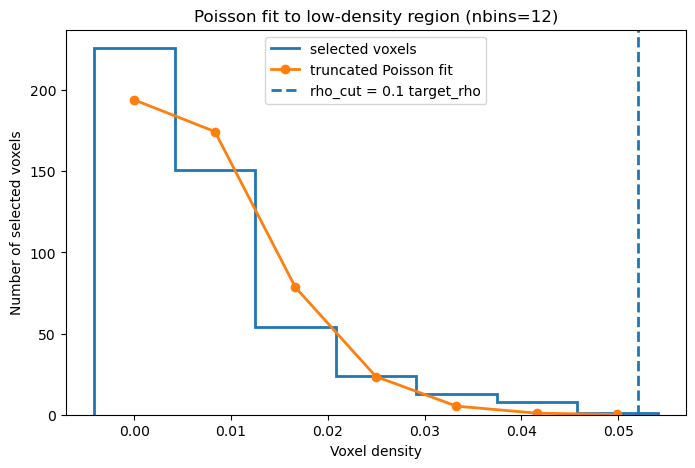

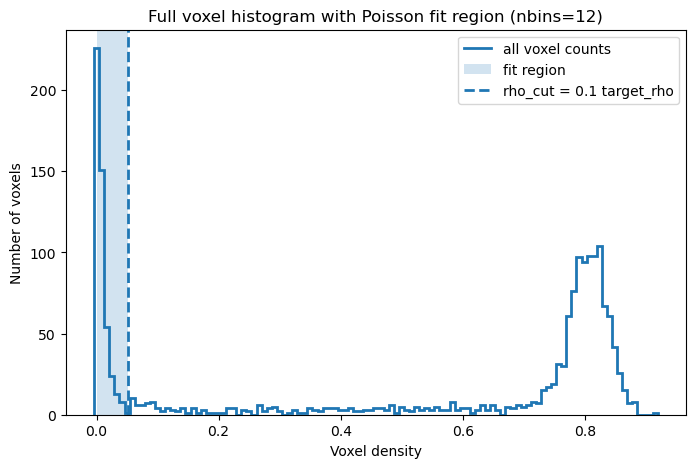

In [12]:
# ============================================================
# Low-density Poisson fit only
#
# Fit a Poisson to voxels with:
#     0 <= voxel_density <= fraction_of_target_rho_to_fit * target_rho
#
# Example:
#     fraction_of_target_rho_to_fit = 0.25
# means:
#     fit from 0 to target_rho / 4
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.special import gammaln


# ============================================================
# User settings
# ============================================================

nbins = 12

# Change this number to choose how far into the histogram you fit.
# 0.25 = fit from 0 to target_rho / 4
# 0.50 = fit from 0 to target_rho / 2
# 1.00 = fit from 0 to target_rho
fraction_of_target_rho_to_fit = 0.1

# If you already know the target rho, set it here.
# Otherwise this tries to read it from the log metadata.
target_rho = None


# ============================================================
# Get target rho from metadata if needed
# ============================================================

if target_rho is None:
    log = lh.read_hdf5_log(result["paths"]["log_path"])
    target_rho = float(log["metadata"]["attrs"]["target_rho"])

rho_cut = fraction_of_target_rho_to_fit * target_rho

print("Low-density Poisson fit")
print("=" * 70)
print(f"target_rho = {target_rho}")
print(f"fraction_of_target_rho_to_fit = {fraction_of_target_rho_to_fit}")
print(f"rho_cut = {rho_cut}")
print(f"nbins = {nbins}")
print("=" * 70)


# ============================================================
# Compute voxel densities and counts
# ============================================================

voxel_densities, voxel_counts, voxel_volume = vh.compute_voxel_densities(
    result,
    nbins=nbins,
)

voxel_counts = np.rint(voxel_counts).astype(int)

low_mask = (
    (voxel_densities >= 0.0)
    & (voxel_densities <= rho_cut)
)

low_counts = voxel_counts[low_mask]
low_densities = voxel_densities[low_mask]

n_voxels = len(voxel_counts)
n_low = len(low_counts)

print()
print("Voxel selection")
print("-" * 70)
print(f"total voxels:          {n_voxels}")
print(f"selected voxels:       {n_low}")
print(f"selected fraction:     {n_low / n_voxels:.6g}")
print(f"voxel_volume:          {voxel_volume:.6g}")

if n_low == 0:
    raise RuntimeError(
        "No voxels were found below the chosen rho_cut. "
        "Try increasing fraction_of_target_rho_to_fit or increasing nbins."
    )


# ============================================================
# Build histogram for selected low-density voxels
# ============================================================

k_min = 0
k_max = int(low_counts.max())

k_values = np.arange(
    k_min,
    k_max + 1,
    dtype=int,
)

hist_counts = np.bincount(
    low_counts,
    minlength=k_max + 1,
)

count_edges = np.arange(
    k_min - 0.5,
    k_max + 1.5,
    1.0,
)

density_edges = count_edges / voxel_volume
density_centers = k_values / voxel_volume


# ============================================================
# Poisson helper
# ============================================================

def poisson_probs(k_values, lam):
    """
    Ordinary Poisson probability P(k | lambda).
    """

    k_values = np.asarray(
        k_values,
        dtype=np.float64,
    )

    lam = max(
        float(lam),
        1e-12,
    )

    log_probs = (
        k_values * np.log(lam)
        - lam
        - gammaln(k_values + 1.0)
    )

    return np.exp(log_probs)


# ============================================================
# Fit truncated Poisson on selected range
# ============================================================

def truncated_poisson_nll(lam):
    """
    Negative log likelihood for selected counts.

    Since we only fit counts from k = 0 to k_max, this uses the
    Poisson distribution conditioned on being in that range.
    """

    probs = poisson_probs(
        k_values,
        lam,
    )

    norm = np.sum(probs)

    if norm <= 0:
        return np.inf

    probs = probs / norm
    probs = np.clip(probs, 1e-300, None)

    nll = -np.sum(
        hist_counts * np.log(probs)
    )

    return float(nll)


lambda_mean_selected = float(np.mean(low_counts))

upper_lam = max(
    10.0,
    k_max + 10.0,
    lambda_mean_selected + 10.0,
)

res = minimize_scalar(
    truncated_poisson_nll,
    bounds=(1e-12, upper_lam),
    method="bounded",
    options={
        "xatol": 1e-12,
    },
)

lambda_fit = float(res.x)

p_fit_trunc = poisson_probs(
    k_values,
    lambda_fit,
)

p_fit_trunc = p_fit_trunc / np.sum(p_fit_trunc)

expected_counts = n_low * p_fit_trunc

nll = truncated_poisson_nll(lambda_fit)


# ============================================================
# Print fit result
# ============================================================

print()
print("Poisson fit result")
print("-" * 70)
print(f"k range used:              {k_min} to {k_max}")
print(f"density range used:        0 to {rho_cut:.6g}")
print(f"mean selected count:       {lambda_mean_selected:.6g}")
print(f"truncated-Poisson lambda:  {lambda_fit:.6g}")
print(f"rho_lambda:                {lambda_fit / voxel_volume:.6g}")
print(f"NLL:                       {nll:.6g}")
print(f"optimizer success:         {res.success}")
print(f"optimizer message:         {res.message}")
print("=" * 70)


# ============================================================
# Plot selected low-density fit only
# ============================================================

plt.figure(figsize=(8, 5))

plt.stairs(
    hist_counts,
    edges=density_edges,
    linewidth=2,
    label="selected voxels",
)

plt.plot(
    density_centers,
    expected_counts,
    marker="o",
    linewidth=2,
    label="truncated Poisson fit",
)

plt.axvline(
    rho_cut,
    linestyle="--",
    linewidth=2,
    label=f"rho_cut = {fraction_of_target_rho_to_fit} target_rho",
)

plt.xlabel("Voxel density")
plt.ylabel("Number of selected voxels")
plt.title(f"Poisson fit to low-density region (nbins={nbins})")
plt.legend()
plt.show()


# ============================================================
# Plot full histogram with selected fit region
# ============================================================

all_k_max = int(voxel_counts.max())

all_hist_counts = np.bincount(
    voxel_counts,
    minlength=all_k_max + 1,
)

all_count_edges = np.arange(
    -0.5,
    all_k_max + 1.5,
    1.0,
)

all_density_edges = all_count_edges / voxel_volume

plt.figure(figsize=(8, 5))

plt.stairs(
    all_hist_counts,
    edges=all_density_edges,
    linewidth=2,
    label="all voxel counts",
)

plt.axvspan(
    0.0,
    rho_cut,
    alpha=0.2,
    label="fit region",
)

plt.axvline(
    rho_cut,
    linestyle="--",
    linewidth=2,
    label=f"rho_cut = {fraction_of_target_rho_to_fit} target_rho",
)

plt.xlabel("Voxel density")
plt.ylabel("Number of voxels")
plt.title(f"Full voxel histogram with Poisson fit region (nbins={nbins})")
plt.legend()
plt.show()